In [5]:
import wandb
import pandas as pd
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

entity = "bsarec"
project = "new_datasets"

api = wandb.Api()
runs = api.runs(f"{entity}/{project}")

models = ["BSARec"]
models_seen = {name: False for name in models}
metrics = ["HR@20", "NDCG@20"]
columns = ["model_name", "dataset", "metric", "value", "c", "alpha", "num_heads", "learning_rate"]
data = []

for run in runs:
    if run.state != "finished":
        continue

    model_name = run.config.get("model_type", None)

    if model_name is None or model_name not in models:
        continue

    models_seen[model_name] = True

    dataset = run.config.get("data_name", None)

    for metric_name in metrics:
        metric_value = run.summary.get(f"test/{metric_name}", None)
        c = run.config.get("c", None)
        alpha = run.config.get("alpha", None)
        num_heads = run.config.get("num_attention_heads", None)
        lr = run.config.get("lr", None)

        if metric_value is None:
            continue

        data.append([
            model_name,
            dataset,
            metric_name,
            metric_value,
            c,
            alpha,
            num_heads,
            lr,
        ])

print("Models seen:", models_seen)


Models seen: {'BSARec': True}


In [6]:
df = pd.DataFrame(data, columns=columns)


In [7]:
df

,model_name,dataset,metric,value,c,alpha,num_heads,learning_rate
0,BSARec,MIND,HR@20,0.192473,5,0.7,1,0.0005
1,BSARec,MIND,NDCG@20,0.087105,5,0.7,1,0.0005
2,BSARec,MIND,HR@20,0.201882,5,0.7,1,0.0005
3,BSARec,MIND,NDCG@20,0.092057,5,0.7,1,0.0005
4,BSARec,MIND,HR@20,0.239528,7,0.1,1,0.0100
...,...,...,...,...,...,...,...,...
621,BSARec,ML-1M,NDCG@20,0.225068,9,0.3,4,0.0005
622,BSARec,ML-1M,HR@20,0.448510,9,0.3,4,0.0005
623,BSARec,ML-1M,NDCG@20,0.225779,9,0.3,4,0.0005
624,BSARec,ML-1M,HR@20,0.448344,9,0.3,4,0.0005


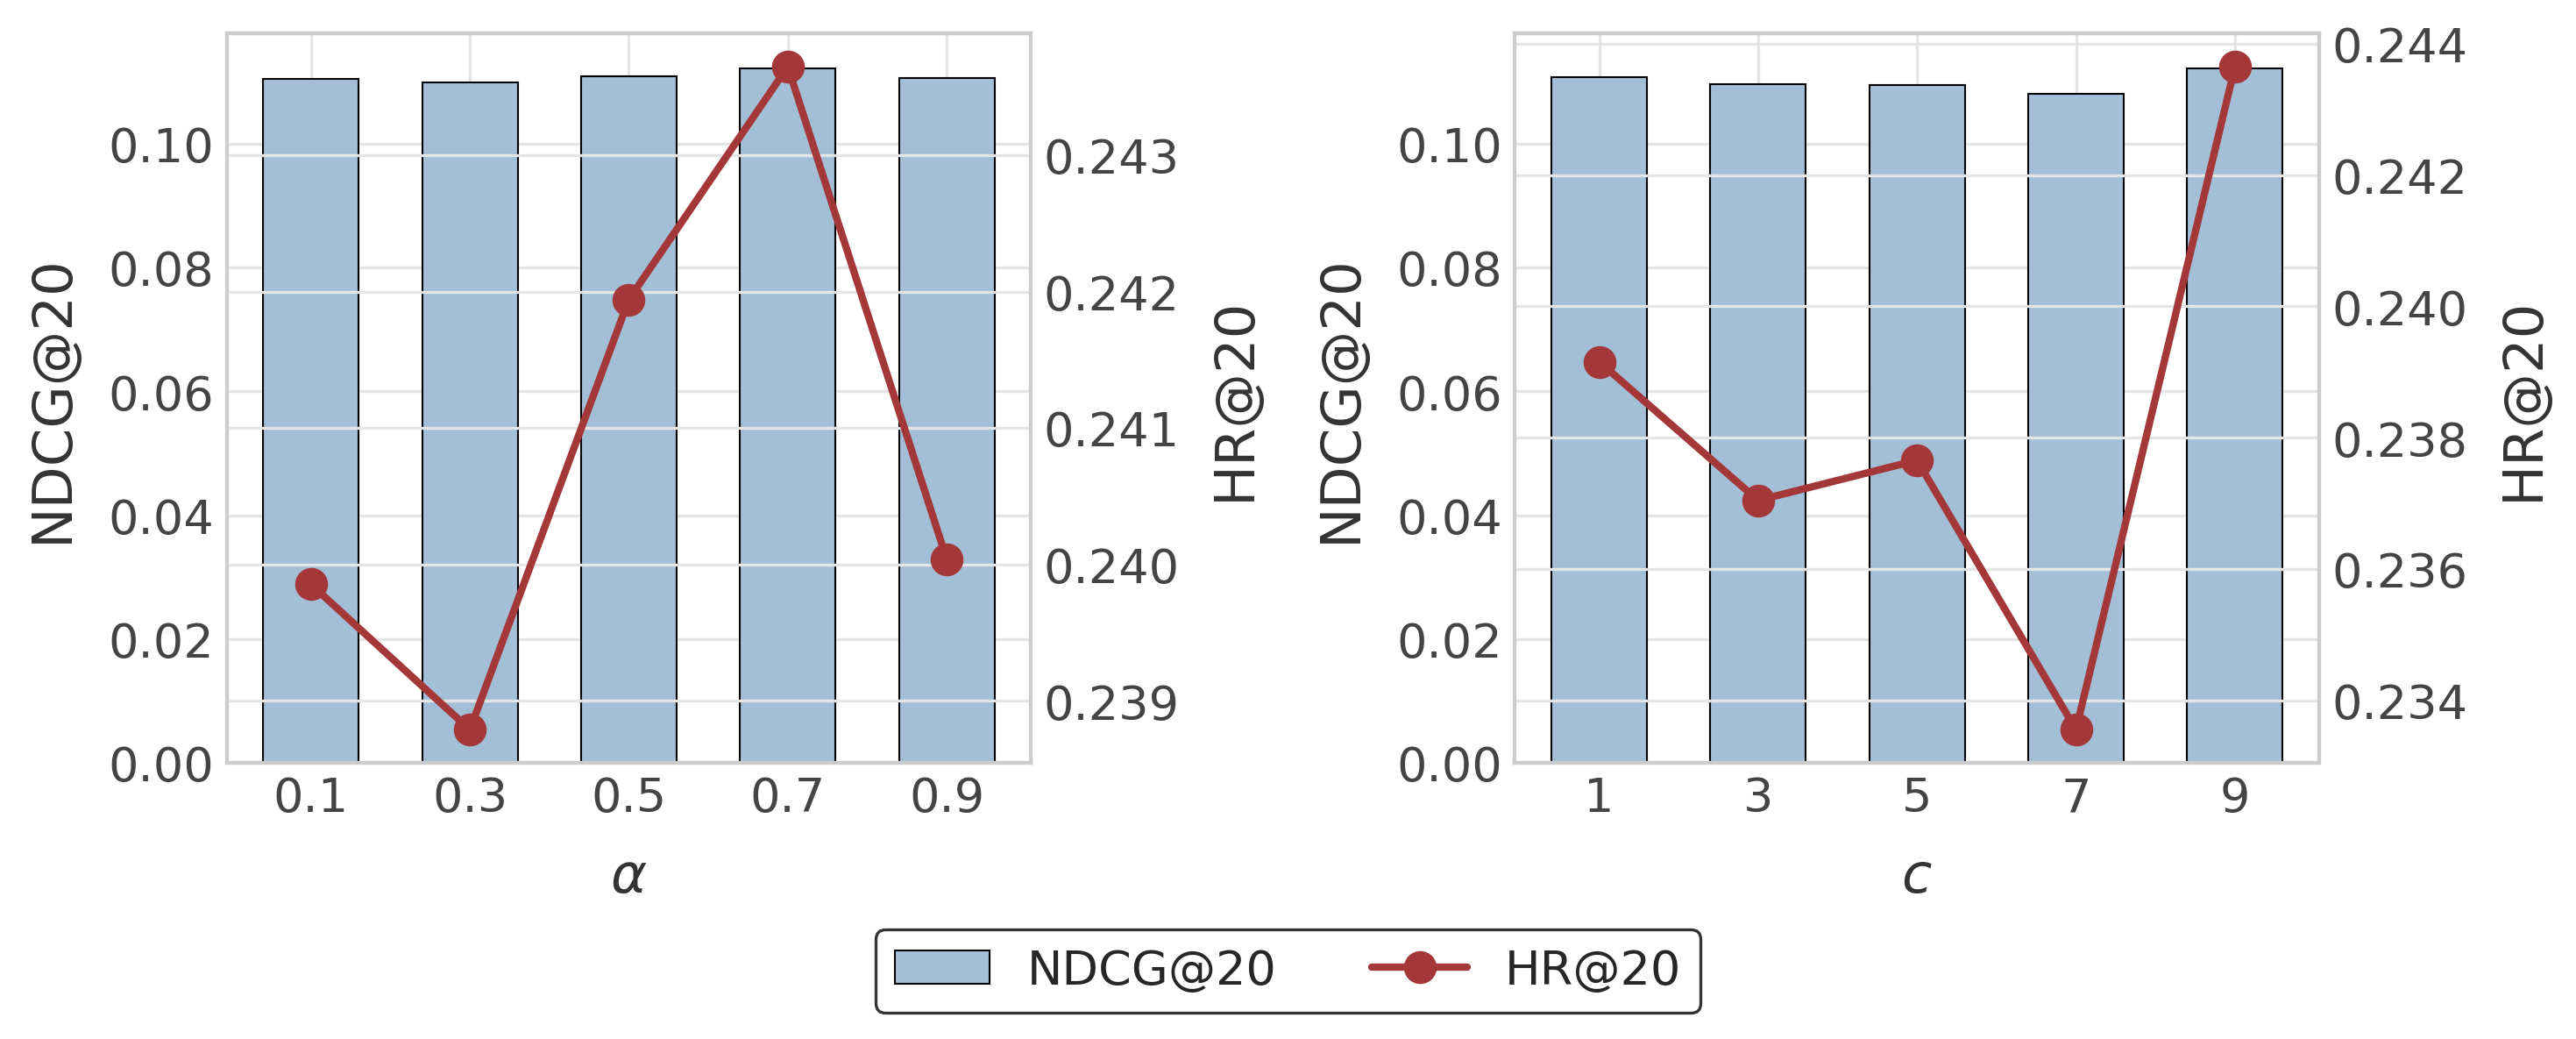

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only MIND-related data
df_filtered = df[
    (df["c"] == 9) & 
    (df["learning_rate"] == 0.005) & 
    (df["num_heads"] == 1) &
    (df["dataset"] == "MIND")
].copy()

df_filtered_c = df[
    (df["alpha"] == 0.7) & 
    (df["learning_rate"] == 0.005) & 
    (df["num_heads"] == 1) &
    (df["dataset"] == "MIND")
].copy()

# Pivot tables
df_pivot = (
    df_filtered
    .groupby(["alpha", "metric"])["value"]
    .mean()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values(by="alpha")
)

df_pivot_c = (
    df_filtered_c
    .groupby(["c", "metric"])["value"]
    .mean()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values(by="c")
)

# Plotting
sns.set_style("whitegrid", {
    "grid.color":    "#e5e5e5",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.0,
})
sns.set_context("paper", font_scale=1.4)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.labelcolor":   "#333333",
    "xtick.color":       "#444444",
    "ytick.color":       "#444444",
    "axes.titlesize":    18,
    "axes.titleweight":  "bold",
    "axes.labelsize":    15,
    "legend.fontsize":   13,
    "xtick.labelsize":   13,
    "ytick.labelsize":   13,
    "figure.dpi":        300,
    "figure.facecolor":  "white",
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharex=False)

bar_color = "#a3bfd8"
line_color = "#A43737"

# Plot for alpha
ax1 = axes[0]
ax1_twin = ax1.twinx()
bars1 = ax1.bar(
    df_pivot["alpha"].astype(str),
    df_pivot["NDCG@20"],
    color=bar_color,
    width=0.6,
    edgecolor="none",
    zorder=2
)
line1, = ax1_twin.plot(
    df_pivot["alpha"].astype(str),
    df_pivot["HR@20"],
    linestyle="-",
    marker="o",
    markersize=8,
    linewidth=2,
    color=line_color,
    zorder=3
)
for bar in bars1:
    bar.set_edgecolor("black")
    bar.set_linewidth(0.5)

ax1.set_xlabel(r'$\alpha$', labelpad=8)
ax1.set_ylabel("NDCG@20", labelpad=8)
ax1_twin.set_ylabel("HR@20", labelpad=8)

ax1.tick_params(axis="x", length=0)
ax1.tick_params(axis="y", length=0)
ax1_twin.tick_params(axis="y", length=0)

# Plot for c
ax2 = axes[1]
ax2_twin = ax2.twinx()
bars2 = ax2.bar(
    df_pivot_c["c"].astype(str),
    df_pivot_c["NDCG@20"],
    color=bar_color,
    width=0.6,
    edgecolor="none",
    zorder=2
)
line2, = ax2_twin.plot(
    df_pivot_c["c"].astype(str),
    df_pivot_c["HR@20"],
    linestyle="-",
    marker="o",
    markersize=8,
    linewidth=2,
    color=line_color,
    zorder=3
)
for bar in bars2:
    bar.set_edgecolor("black")
    bar.set_linewidth(0.5)

ax2.set_xlabel(r"$c$", labelpad=8)
ax2.set_ylabel("NDCG@20", labelpad=8)
ax2_twin.set_ylabel("HR@20", labelpad=8)

ax2.tick_params(axis="x", length=0)
ax2.tick_params(axis="y", length=0)
ax2_twin.tick_params(axis="y", length=0)

# Legend and layout
handles = [bars1[0], line1]
labels = ["NDCG@20", "HR@20"]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.savefig("ndcg_hr_alpha_and_c_mind_only.pdf", format="pdf")
plt.show()
